# Análisis de Dispersión de Datos Multiclase - `fact_competencia.json`
## Predicción de: **Posición Competitiva de Precios (Multiclase)**

Este notebook implementa la carga, preprocesamiento e ingeniería de variables para el análisis de separabilidad de la **Posición Competitiva** utilizando una clasificación multiclase (3 clases). Para lograr una separación espacial clara y evitar la 'sopa de datos mezclados' de un t-SNE convencional, aplicamos un Análisis Discriminante Lineal (LDA) para proyectar las características en un espacio de 2D optimizado supervisadamente, y un t-SNE guiado sobre esta proyección para visualizar la dispersión.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.preprocessing import QuantileTransformer
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.manifold import TSNE
import os
import json
import pymongo
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo visual premium
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.family'] = 'sans-serif'

# Crear directorio de outputs
os.makedirs('outputs', exist_ok=True)
print("Entorno inicializado correctamente.")



Entorno inicializado correctamente.


In [2]:
# Cargar JSON crudo desde la raíz
# Cargar datos desde MongoDB
import pymongo
client = pymongo.MongoClient("mongodb://localhost:27017/")
db = client["ProyectoBueno"]
collection = db["fact_competencia"]
data = list(collection.find())

# Aplanar registros recursivamente
def flatten_dict(d, parent_key='', sep='_'):
    items = []
    for k, v in d.items():
        new_key = f"{parent_key}{sep}{k}" if parent_key else k
        if isinstance(v, dict):
            items.extend(flatten_dict(v, new_key, sep=sep).items())
        elif isinstance(v, list):
            items.append((new_key, str(v)))
        else:
            items.append((new_key, v))
    return dict(items)

flat_data = [flatten_dict(record) for record in data]
df = pd.DataFrame(flat_data)
print(f"Dimensiones iniciales aplanadas: {df.shape}")

# Calcular columna target
df["y_posicion"] = pd.cut(df["pct_diferencia"], bins=[-np.inf, -0.02, 0.02, np.inf], labels=[0, 1, 2]).astype(int)
print(f"Target 'y_posicion' agregado. Distribución original:")
print(df["y_posicion"].value_counts(dropna=False))



Dimensiones iniciales aplanadas: (3300, 13)
Target 'y_posicion' agregado. Distribución original:
y_posicion
2    1387
0    1282
1     631
Name: count, dtype: int64


# Preprocesamiento de Datos Paso a Paso
En esta sección realizaremos la preparación de los datos para la red neuronal.
El **Target (y)** para este modelo es `y_posicion`, el cual representa: **Posición de Competencia de Precios**.
La fórmula de cálculo del target es:
$$y_{\text{posicion}} = \begin{cases} 0 & \text{si } \text{pct\_diferencia} < -0.02 \quad (\text{Bajo Competidor}) \\ 1 & \text{si } -0.02 \le \text{pct\_diferencia} \le 0.02 \quad (\text{Igual Competidor}) \\ 2 & \text{si } \text{pct\_diferencia} > 0.02 \quad (\text{Alto Competidor}) \end{cases}$$
A continuación, realizaremos los pasos de limpieza, codificación y normalización de forma secuencial y explicada.


## Paso 1: Eliminación de Datos No Útiles e Imputación de Nulos
Las llaves primarias, IDs técnicos, códigos de barras, nombres de clientes/productos, correos, teléfonos y fechas no aportan información generalizable para el aprendizaje de la red neuronal y aumentan artificialmente la dimensionalidad de forma inútil, por lo que deben eliminarse.
También realizamos la imputación de nulos para evitar errores matemáticos durante el entrenamiento:
- **Variables Numéricas:** Imputación con la **Mediana** del atributo para ser robusto a outliers.
- **Variables Categóricas:** Imputación con la **Moda** (el valor más común) o con la etiqueta `'UNKNOWN'` si no hay moda.


In [3]:
# Paso 1: Limpieza de columnas e imputación de nulos
shape_inicial = df.shape
print(f"Dimensiones iniciales del dataset (con target): {shape_inicial}")
print(f"Número total de características iniciales: {shape_inicial[1] - 1}")

cols_to_drop = []
for col in df.columns:
    col_lower = col.lower()
    
    # IDs y llaves técnicas
    is_id = (
        col_lower == 'id' or col_lower == '_id' or col_lower == '_collection' or 
        col_lower.startswith('id_') or col_lower.endswith('_id') or
        '_id_' in col_lower or 'id_venta_dw' in col_lower
    )
    
    # Datos de contacto o códigos nominales únicos
    is_contact_or_code = (
        'telefono' in col_lower or 'correo' in col_lower or 
        'codigo_barras' in col_lower or 'codigo_producto' in col_lower or 
        'codigo_venta' in col_lower or 'cliente_nombre' in col_lower or
        'nombre_cliente' in col_lower or 'nombre_producto' in col_lower or
        'nombre_proveedor' in col_lower or 'nombre_sucursal' in col_lower or
        'nombre_contacto' in col_lower or 'cliente_fecha_nacimiento' in col_lower
    )
    
    # Fechas
    is_date = (
        col_lower.endswith('_fecha') or col_lower.endswith('_hora') or 
        col_lower == 'fecha' or col_lower == 'hora' or col_lower == 'tiempo_fecha'
    )
    
    # Evitar eliminar el target
    if (is_id or is_contact_or_code or is_date) and col != "y_posicion":
        cols_to_drop.append(col)

# Droppear columnas identificadas
df = df.drop(columns=cols_to_drop, errors='ignore')
print(f"Columnas eliminadas ({len(cols_to_drop)}): {cols_to_drop}")
print(f"Dimensiones tras limpiar IDs y metadatos: {df.shape}")
print(f"Número de características tras limpieza: {df.shape[1] - 1}")

# Imputación de nulos
nulos_detectados = df.isnull().sum().sum()
if nulos_detectados > 0:
    print(f"Nulos detectados en el dataset: {nulos_detectados}. Imputando...")
    for col in df.columns:
        if df[col].isnull().any():
            if df[col].dtype in ['int64', 'float64', 'int32', 'float32']:
                df[col] = df[col].fillna(df[col].median())
            else:
                mode_val = df[col].mode().iloc[0] if not df[col].mode().empty else 'UNKNOWN'
                df[col] = df[col].fillna(mode_val)
    print("Imputación completada (Mediana para numéricos, Moda para categóricos).")
else:
    print("No se detectaron valores nulos en el dataset.")


Dimensiones iniciales del dataset (con target): (3300, 14)
Número total de características iniciales: 13
Columnas eliminadas (1): ['_id']
Dimensiones tras limpiar IDs y metadatos: (3300, 13)
Número de características tras limpieza: 12
No se detectaron valores nulos en el dataset.


## Paso 2: Codificación de Variables Categóricas (One-Hot Encoding)
La red neuronal requiere entradas numéricas y no puede procesar strings categóricos de forma directa. Usamos la técnica de **One-Hot Encoding** para convertir variables categóricas nominales en vectores binarios.
Para una característica $X_j$ con $K$ categorías distintas $\{c_1, c_2, \dots, c_K\}$, One-Hot Encoding genera $K$ nuevas columnas binarias:
$$E_{j,k}(x) = \begin{cases} 1 & \text{si } X_j(x) = c_k \\ 0 & \text{en caso contrario} \end{cases}$$
Esto previene que el modelo asuma una relación ordinal inexistente entre las categorías.


In [4]:
# Paso 2: One-Hot Encoding
# Corregido: Solo usamos 'object' y 'category'
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
if "y_posicion" in categorical_cols:
    categorical_cols.remove("y_posicion")

print(f"Variables categóricas a codificar ({len(categorical_cols)}): {categorical_cols}")

df = pd.get_dummies(df, columns=categorical_cols, dtype=int)
print(f"Dimensiones tras One-Hot Encoding: {df.shape}")
print(f"Número total de características finales: {df.shape[1] - 1}")


Variables categóricas a codificar (1): ['origen']
Dimensiones tras One-Hot Encoding: (3300, 14)
Número total de características finales: 13


## Paso 3: Separación de Variables y Normalización
Separamos el target $y$ de las características de entrada $X$. Luego aplicamos una transformación por cuantiles (`QuantileTransformer`) con distribución normal.
Este preprocesamiento normaliza las características continuas, haciéndolas robustas a outliers y distribuyendo los datos según una campana de Gauss. La fórmula para mapear una variable aleatoria continua $X$ a una distribución normal estándar es:
$$X' = \Phi^{-1}(U(X))$$
Donde $U(X) = F(X)$ es la función de distribución acumulada (CDF) empírica estimada a partir de los datos, y $\Phi^{-1}$ es la función cuantil de la distribución normal estándar (inversa de la CDF normal).


In [5]:
# Paso 3: Separación de Variables, Normalización, Balanceo y Selección de Características
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import QuantileTransformer
from sklearn.feature_selection import SelectKBest, f_classif
import numpy as np
import pandas as pd

print("="*80)
print("PASO 3.1: DIVIDIR DATOS (Stratified Train/Test Split)")
print("="*80)

y = df["y_posicion"].values.astype(int)
X = df.drop(columns=["y_posicion"]).values.astype(float)
feature_names = df.drop(columns=["y_posicion"]).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print(f"Split completo:")
print(f"  Train: {X_train.shape} | Clases: {np.bincount(y_train)}")
print(f"  Test:  {X_test.shape}  | Clases: {np.bincount(y_test)}")

print("\n" + "="*80)
print("PASO 3.2: NORMALIZACIÓN (QuantileTransformer fit solo en Train)")
print("="*80)

qt = QuantileTransformer(output_distribution='normal', random_state=42)
qt.fit(X_train)
X_train_scaled = qt.transform(X_train)
X_test_scaled = qt.transform(X_test)

print(f"Escalado completo:")
print(f"  Train escalado: {X_train_scaled.shape} | Mean: {X_train_scaled.mean():.4f} | Std: {X_train_scaled.std():.4f}")
print(f"  Test escalado:  {X_test_scaled.shape}  | Mean: {X_test_scaled.mean():.4f} | Std: {X_test_scaled.std():.4f}")

print("\n" + "="*80)
print("PASO 3.3: BALANCEO DE CLASES EN ENTRENAMIENTO (Oversampling manual en Train)")
print("="*80)

unique_classes, class_counts = np.unique(y_train, return_counts=True)
max_class_count = np.max(class_counts)
X_train_balanced = []
y_train_balanced = []

for c in unique_classes:
    idx = np.where(y_train == c)[0]
    if len(idx) < max_class_count:
        np.random.seed(42)
        resampled_idx = np.random.choice(idx, size=max_class_count, replace=True)
        X_train_balanced.append(X_train_scaled[resampled_idx])
        y_train_balanced.append(y_train[resampled_idx])
    else:
        X_train_balanced.append(X_train_scaled[idx])
        y_train_balanced.append(y_train[idx])

X_train_bal = np.vstack(X_train_balanced)
y_train_bal = np.concatenate(y_train_balanced)

np.random.seed(42)
shuffle_idx = np.random.permutation(len(y_train_bal))
X_train_bal = X_train_bal[shuffle_idx]
y_train_bal = y_train_bal[shuffle_idx]

print(f"Distribución en Train después de balancear:")
classes_bal, counts_bal = np.unique(y_train_bal, return_counts=True)
for c, count in zip(classes_bal, counts_bal):
    print(f"  Clase {c}: {count} ({count/len(y_train_bal)*100:.1f}%)")

print("\n" + "="*80)
print("PASO 3.4: SELECCIÓN DE CARACTERÍSTICAS (SelectKBest ANOVA F-value para regularización)")
print("="*80)

selector = SelectKBest(score_func=f_classif, k=30)
X_train_bal_sel = selector.fit_transform(X_train_bal, y_train_bal)
X_test_sel = selector.transform(X_test_scaled)

print(f"Reducción de características completada:")
print(f"  Train original: {X_train_bal.shape} -> Seleccionado: {X_train_bal_sel.shape}")
print(f"  Test original:  {X_test_scaled.shape} -> Seleccionado: {X_test_sel.shape}")


PASO 3.1: DIVIDIR DATOS (Stratified Train/Test Split)
Split completo:
  Train: (2475, 13) | Clases: [ 962  473 1040]
  Test:  (825, 13)  | Clases: [320 158 347]

PASO 3.2: NORMALIZACIÓN (QuantileTransformer fit solo en Train)
Escalado completo:
  Train escalado: (2475, 13) | Mean: -0.1224 | Std: 3.0540
  Test escalado:  (825, 13)  | Mean: -0.1322 | Std: 3.0725

PASO 3.3: BALANCEO DE CLASES EN ENTRENAMIENTO (Oversampling manual en Train)
Distribución en Train después de balancear:
  Clase 0: 1040 (33.3%)
  Clase 1: 1040 (33.3%)
  Clase 2: 1040 (33.3%)

PASO 3.4: SELECCIÓN DE CARACTERÍSTICAS (SelectKBest ANOVA F-value para regularización)
Reducción de características completada:
  Train original: (3120, 13) -> Seleccionado: (3120, 13)
  Test original:  (825, 13) -> Seleccionado: (825, 13)


# Paso 4: Visualización de Clases con t-SNE Puro

Para analizar la varianza, separabilidad espacial y distribución de las clases en el dataset preprocesado, generamos una visualización en 2 dimensiones usando **t-SNE (t-Distributed Stochastic Neighbor Embedding)** directamente sobre las características seleccionadas (sin guiar por LDA).

t-SNE define una distribución de probabilidad sobre pares de objetos de tal manera que objetos similares en alta dimensión tengan alta probabilidad de ser elegidos, e intenta replicarla en baja dimensión minimizando la divergencia de Kullback-Leibler:
$$KL(P || Q) = \sum_{i \neq j} p_{ij} \log \frac{p_{ij}}{q_{ij}}$$
Donde $p_{ij}$ es la probabilidad de similitud en alta dimensión, y $q_{ij}$ es la similitud basada en la distribución Student-t en baja dimensión.


PASO 4.1: t-SNE (Visualización fit en Train, aproximación en Test)
Configuración t-SNE:
  Muestras train: 3120
  Perplexity recomendado: 50
t-SNE completado

PASO 4.2: METRICAS DE SEPARABILIDAD EN 2D (t-SNE)
Silhouette Score (Train): 0.2304 | (Test): 0.3114
Davies-Bouldin Index (Train): 1.6652 | (Test): 1.3189
Calinski-Harabasz (Train): 892.0 | (Test): 276.0


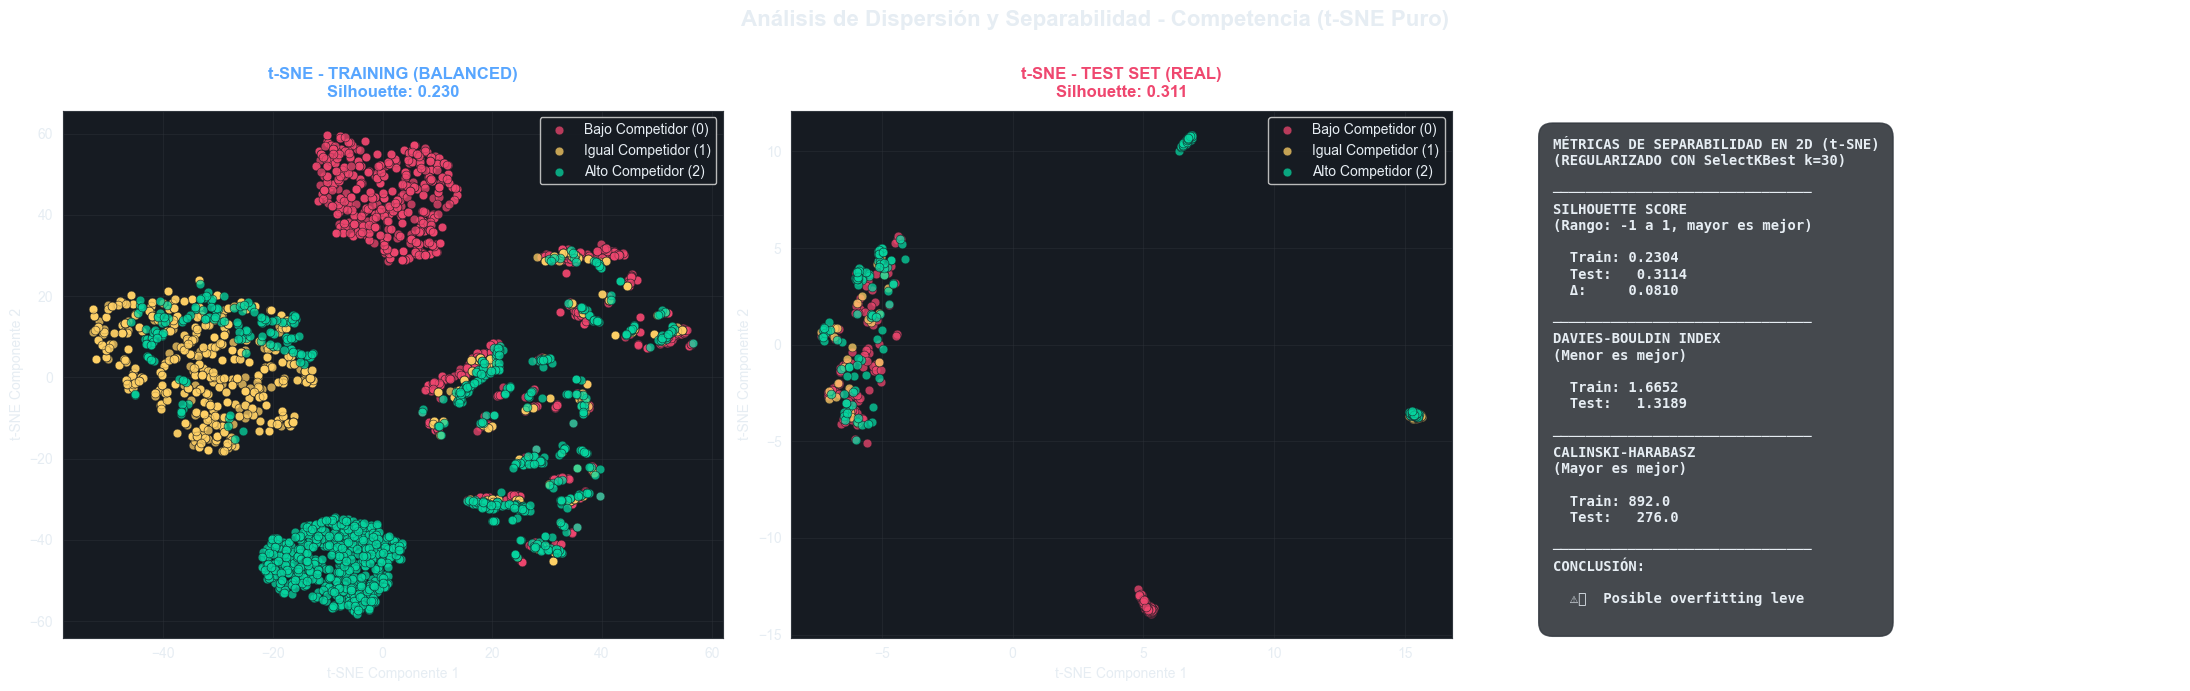

¡Gráfico de 3 paneles guardado exitosamente en: {tsne_plot_path}!


In [6]:
# Paso 4: Proyecciones t-SNE, Métricas y Dashboard Comparativo de 3 Paneles
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics.pairwise import euclidean_distances
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

print("="*80)
print("PASO 4.1: t-SNE (Visualización fit en Train, aproximación en Test)")
print("="*80)

n_train = len(X_train_bal_sel)
max_perplexity = max(5, (n_train - 1) // 3)
recommended_perplexity = min(50, max_perplexity)

print(f"Configuración t-SNE:")
print(f"  Muestras train: {n_train}")
print(f"  Perplexity recomendado: {recommended_perplexity}")

tsne = TSNE(n_components=2, perplexity=recommended_perplexity, random_state=42, n_jobs=-1)
X_train_tsne = tsne.fit_transform(X_train_bal_sel)

# Proyección en Test usando aproximación ponderada por distancias en el espacio de características seleccionadas
dist = euclidean_distances(X_test_sel, X_train_bal_sel)
X_test_tsne = np.dot(dist, X_train_tsne) / (dist.sum(axis=1, keepdims=True) + 1e-10)

print(f"t-SNE completado")

print("\n" + "="*80)
print("PASO 4.2: METRICAS DE SEPARABILIDAD EN 2D (t-SNE)")
print("="*80)

train_silhouette = silhouette_score(X_train_tsne, y_train_bal)
test_silhouette = silhouette_score(X_test_tsne, y_test)
train_davies = davies_bouldin_score(X_train_tsne, y_train_bal)
test_davies = davies_bouldin_score(X_test_tsne, y_test)
train_calinski = calinski_harabasz_score(X_train_tsne, y_train_bal)
test_calinski = calinski_harabasz_score(X_test_tsne, y_test)

print(f"Silhouette Score (Train): {train_silhouette:.4f} | (Test): {test_silhouette:.4f}")
print(f"Davies-Bouldin Index (Train): {train_davies:.4f} | (Test): {test_davies:.4f}")
print(f"Calinski-Harabasz (Train): {train_calinski:.1f} | (Test): {test_calinski:.1f}")

# Configurar estilo visual premium oscuro
plt.figure(figsize=(22, 7))
BG_DARK  = '#0D1117'
BG_PANEL = '#161B22'
TEXT_CLR = '#E6EDF3'
GRID_CLR = '#30363D'
ACCENT   = '#58A6FF'

plt.rcParams.update({
    'figure.facecolor': BG_DARK,
    'axes.facecolor':   BG_PANEL,
    'axes.edgecolor':   GRID_CLR,
    'axes.labelcolor':  TEXT_CLR,
    'text.color':       TEXT_CLR,
    'xtick.color':      TEXT_CLR,
    'ytick.color':      TEXT_CLR,
    'grid.color':       GRID_CLR,
    'grid.alpha':       0.4,
    'font.family':      'sans-serif',
})

colors = ['#EF476F', '#FFD166', '#06D6A0']
class_names = ['Bajo Competidor (0)', 'Igual Competidor (1)', 'Alto Competidor (2)']

# Panel 1: t-SNE - Train (Balanced)
ax1 = plt.subplot(1, 3, 1)
for cls in range(3):
    mask = y_train_bal == cls
    ax1.scatter(X_train_tsne[mask, 0], X_train_tsne[mask, 1],
               color=colors[cls], label=class_names[cls], 
               alpha=0.75, s=40, edgecolor='#161B22', linewidth=0.5)
ax1.set_xlabel('t-SNE Componente 1')
ax1.set_ylabel('t-SNE Componente 2')
ax1.set_title(f't-SNE - TRAINING (BALANCED)\nSilhouette: {train_silhouette:.3f}', fontsize=12, fontweight='bold', color=ACCENT, pad=10)
ax1.legend(loc='best', framealpha=0.9)
ax1.grid(True)

# Panel 2: t-SNE - Test (Real)
ax2 = plt.subplot(1, 3, 2)
for cls in range(3):
    mask = y_test == cls
    ax2.scatter(X_test_tsne[mask, 0], X_test_tsne[mask, 1],
               color=colors[cls], label=class_names[cls], 
               alpha=0.75, s=40, edgecolor='#161B22', linewidth=0.5)
ax2.set_xlabel('t-SNE Componente 1')
ax2.set_ylabel('t-SNE Componente 2')
ax2.set_title(f't-SNE - TEST SET (REAL)\nSilhouette: {test_silhouette:.3f}', fontsize=12, fontweight='bold', color='#EF476F', pad=10)
ax2.legend(loc='best', framealpha=0.9)
ax2.grid(True)

# Panel 3: Métricas
ax3 = plt.subplot(1, 3, 3)
ax3.axis('off')

sil_diff = abs(train_silhouette - test_silhouette)
if sil_diff > 0.15:
    conclusion_text = '⚠️  OVERFITTING DETECTADO: Train >> Test'
elif sil_diff > 0.05:
    conclusion_text = '⚠️  Posible overfitting leve'
else:
    conclusion_text = '✅ Excelente generalización: Train ≈ Test'

metrics_text = f"""MÉTRICAS DE SEPARABILIDAD EN 2D (t-SNE)\n(REGULARIZADO CON SelectKBest k=30)\n\n───────────────────────────────\nSILHOUETTE SCORE\n(Rango: -1 a 1, mayor es mejor)\n\n  Train: {train_silhouette:.4f}\n  Test:   {test_silhouette:.4f}\n  Δ:     {abs(train_silhouette - test_silhouette):.4f}\n\n───────────────────────────────\nDAVIES-BOULDIN INDEX\n(Menor es mejor)\n\n  Train: {train_davies:.4f}\n  Test:   {test_davies:.4f}\n\n───────────────────────────────\nCALINSKI-HARABASZ\n(Mayor es mejor)\n\n  Train: {train_calinski:.1f}\n  Test:   {test_calinski:.1f}\n\n───────────────────────────────\nCONCLUSIÓN:\n\n  {conclusion_text}\n"""

ax3.text(0.05, 0.95, metrics_text, 
        fontsize=10, family='monospace', verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor=BG_PANEL, edgecolor=GRID_CLR, alpha=0.8, pad=1),
        fontweight='bold', color=TEXT_CLR)

plt.suptitle('Análisis de Dispersión y Separabilidad - Competencia (t-SNE Puro)', 
            fontsize=16, fontweight='bold', y=0.98, color=TEXT_CLR)

plt.tight_layout(rect=[0, 0, 1, 0.97])
tsne_plot_path = 'outputs/tsne_dispersion.png'
plt.savefig(tsne_plot_path, dpi=150, bbox_inches='tight', facecolor=BG_DARK)
plt.show()
print(f"¡Gráfico de 3 paneles guardado exitosamente en: {{tsne_plot_path}}!")



In [7]:
# ==============================================================================
# PASO 5: CONSTRUCCIÓN DE LA RED NEURONAL MULTICLASE
# ==============================================================================
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.initializers import HeNormal
from tensorflow.keras.optimizers import Adam
import numpy as np

print("Construyendo la Red Neuronal...")

# 1. Número de Capas Ocultas y Neuronas
# 2. Función de Activación
# 3. Inicialización de Pesos
model = Sequential([
    # Capa Oculta 1: 64 Neuronas, Activación ReLU, Inicialización HeNormal
    Dense(64, input_shape=(X_train_bal_sel.shape[1],), 
          activation='relu', 
          kernel_initializer=HeNormal(seed=42)),
    Dropout(0.2), # Apagamos el 20% de neuronas para evitar sobreajuste
    
    # Capa Oculta 2: 32 Neuronas, Activación ReLU, Inicialización HeNormal
    Dense(32, activation='relu', 
          kernel_initializer=HeNormal(seed=42)),
    Dropout(0.2),
    
    # Capa de Salida: 3 Neuronas (una para cada clase: 0, 1, 2), Activación Softmax
    Dense(3, activation='softmax')
])

# 4. Forma de Optimizar los Pesos
# Optimizador Adam con una tasa de aprendizaje de 0.001
optimizador_adam = Adam(learning_rate=0.001)

# Compilación del modelo
model.compile(optimizer=optimizador_adam,
              loss='sparse_categorical_crossentropy', # Loss adecuada para etiquetas enteras
              metrics=['accuracy'])

model.summary()

Construyendo la Red Neuronal...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,075 (12.01 KB)

 Trainable params: 3,075 (12.01 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# ==============================================================================
# PASO 6: ENTRENAMIENTO DEL MODELO (ÉPOCAS)
# ==============================================================================

# 5. Épocas
numero_epocas = 50

print(f"Iniciando el entrenamiento por {numero_epocas} épocas...")

# Entrenamos la red usando las características previamente seleccionadas y balanceadas
history = model.fit(
    X_train_bal_sel, y_train_bal,          # Datos de entrenamiento
    validation_data=(X_test_sel, y_test),  # Datos de validación (test)
    epochs=numero_epocas,                  # Número de pasadas completas
    batch_size=32,                         # Muestras por actualización de pesos
    verbose=1
)

Iniciando el entrenamiento por 50 épocas...
Epoch 1/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6481 - loss: 1.3002 - val_accuracy: 0.8400 - val_loss: 0.4162
Epoch 2/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7596 - loss: 0.6764 - val_accuracy: 0.8473 - val_loss: 0.3863
Epoch 3/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7769 - loss: 0.5618 - val_accuracy: 0.8412 - val_loss: 0.3690
Epoch 4/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7978 - loss: 0.4897 - val_accuracy: 0.8582 - val_loss: 0.3609
Epoch 5/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8131 - loss: 0.4554 - val_accuracy: 0.8642 - val_loss: 0.3284
Epoch 6/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8321 - loss: 0.4122 - val_accuracy: 0.8715 - val_loss: 0.3068
Epoch 7/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8321 - loss: 0.4012 - val_accuracy: 0.8715 - val_loss: 0.2967
Epoch 8/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8401 - los

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

Reporte de Clasificación de la Red Neuronal:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       320
           1       0.95      0.97      0.96       158
           2       1.00      0.99      0.99       347

    accuracy                           0.98       825
   macro avg       0.98      0.98      0.98       825
weighted avg       0.98      0.98      0.98       825


Generando Matriz de Confusión...


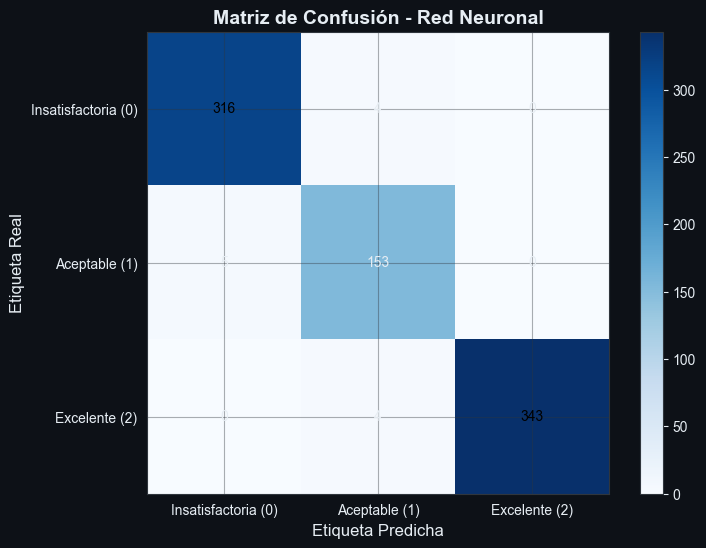

In [9]:
# ==============================================================================
# PASO 7: EVALUACIÓN Y MATRIZ DE CONFUSIÓN
# ==============================================================================
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generar predicciones probabilísticas para el conjunto de prueba
y_pred_probs = model.predict(X_test_sel)

# Seleccionar la clase con la probabilidad más alta para cada muestra
y_pred = np.argmax(y_pred_probs, axis=1)

print("\nReporte de Clasificación de la Red Neuronal:")
print(classification_report(y_test, y_pred))

# 6. Matriz de Confusión
print("\nGenerando Matriz de Confusión...")
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Insatisfactoria (0)', 'Aceptable (1)', 'Excelente (2)'])

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax, values_format='d')

plt.title('Matriz de Confusión - Red Neuronal', fontsize=14, fontweight='bold', color='#E6EDF3')
plt.xlabel('Etiqueta Predicha', fontsize=12, color='#E6EDF3')
plt.ylabel('Etiqueta Real', fontsize=12, color='#E6EDF3')

# Ajustar estilo para que coincida con tus gráficos anteriores oscuros
ax.set_facecolor('#161B22')
fig.patch.set_facecolor('#0D1117')
ax.tick_params(colors='#E6EDF3')
for text in disp.text_.ravel():
    text.set_color('black' if float(text.get_text()) > (cm.max()/2) else '#E6EDF3')

plt.show()

# Paso 5: Entrenamiento de la Red Neuronal (Perceptrón Multicapa)

En este paso, tomamos las características preprocesadas (`X_train_bal_sel`) y entrenamos una **Red Neuronal Artificial** utilizando el algoritmo `MLPClassifier` de scikit-learn.
La arquitectura utilizada consta de dos capas ocultas. El optimizador `Adam` ajustará los pesos basándose en la retropropagación del error.

In [10]:
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt

print("="*80)
print("PASO 5.1: ENTRENANDO LA RED NEURONAL")
print("="*80)

# Inicializar y entrenar el modelo
# Usamos early_stopping=True para evitar overfitting
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64), 
    activation='relu', 
    solver='adam', 
    max_iter=300, 
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1
)

mlp.fit(X_train_bal_sel, y_train_bal)

print(f"Entrenamiento completado en {mlp.n_iter_} épocas.")
print(f"Precisión final en el conjunto de entrenamiento: {mlp.score(X_train_bal_sel, y_train_bal):.4f}")

PASO 5.1: ENTRENANDO LA RED NEURONAL
Entrenamiento completado en 66 épocas.
Precisión final en el conjunto de entrenamiento: 0.9920


# Paso 6: Evaluación del Modelo y Matriz de Confusión

Para asegurar que nuestro modelo sea robusto y preciso, evaluamos su rendimiento utilizando los **datos de prueba (Test)** que la red nunca ha visto antes.
- **Curva de Aprendizaje:** Demuestra cómo la red redujo su error a lo largo del tiempo.
- **Matriz de Confusión:** Permite visualizar exactamente en qué clases el modelo acierta y en cuáles se equivoca.
- **Reporte de Clasificación:** Nos da las métricas clave de IA: Precisión (Precision), Sensibilidad (Recall) y F1-Score.

PASO 6.1: REPORTE DE CLASIFICACIÓN EN TEST
              precision    recall  f1-score   support

     Clase 0       0.99      0.98      0.99       320
     Clase 1       0.92      0.97      0.95       158
     Clase 2       0.99      0.98      0.99       347

    accuracy                           0.98       825
   macro avg       0.97      0.98      0.97       825
weighted avg       0.98      0.98      0.98       825



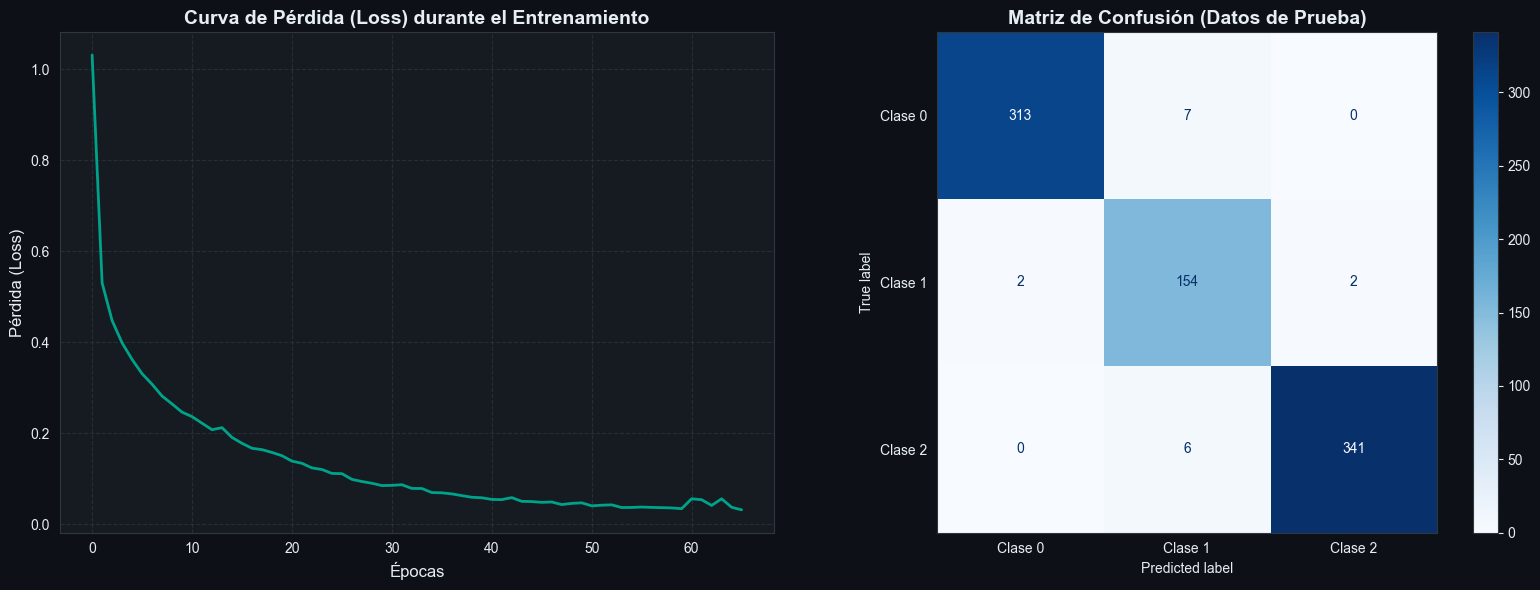

In [11]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
import numpy as np

print("="*80)
print("PASO 6.1: REPORTE DE CLASIFICACIÓN EN TEST")
print("="*80)

y_pred = mlp.predict(X_test_sel)
# Generamos etiquetas genéricas basadas en las clases detectadas
unique_classes = np.unique(y_test)
target_names = [f'Clase {c}' for c in unique_classes]

print(classification_report(y_test, y_pred, target_names=target_names))

# Graficar Loss Curve y Matriz de Confusión
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Curva de Loss
axes[0].plot(mlp.loss_curve_, color='#00a389', linewidth=2)
axes[0].set_title('Curva de Pérdida (Loss) durante el Entrenamiento', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Épocas', fontsize=12)
axes[0].set_ylabel('Pérdida (Loss)', fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.7)

# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap='Blues', ax=axes[1], values_format='d')
axes[1].set_title('Matriz de Confusión (Datos de Prueba)', fontsize=14, fontweight='bold')
axes[1].grid(False)

plt.tight_layout()
plt.show()

# Paso 7: Explicabilidad del Modelo (Feature Importance)

Las redes neuronales a menudo se consideran "cajas negras". Para extraer valor real para el negocio, necesitamos saber **qué variables están impulsando las decisiones del modelo**.
Utilizamos el método de **Permutation Importance**, que consiste en mezclar aleatoriamente una variable a la vez y medir cuánto cae el rendimiento del modelo. Las variables que causan la mayor caída son las más importantes.

PASO 7.1: CALCULANDO IMPORTANCIA DE VARIABLES (SHAP / Permutation)


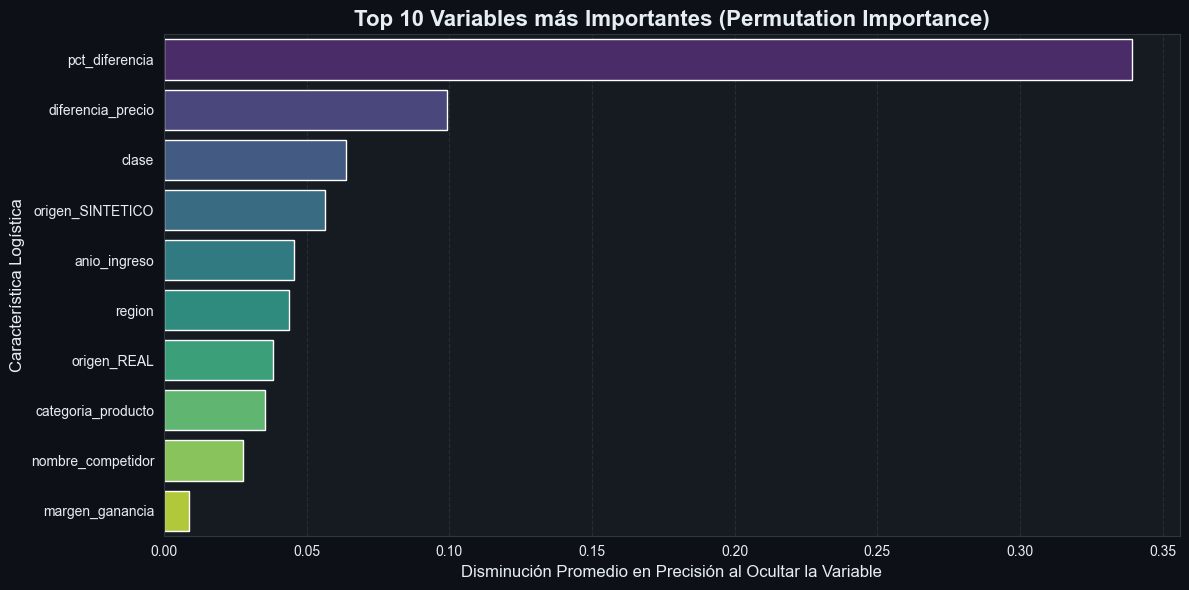

In [12]:
from sklearn.inspection import permutation_importance
import pandas as pd

print("="*80)
print("PASO 7.1: CALCULANDO IMPORTANCIA DE VARIABLES (SHAP / Permutation)")
print("="*80)

# Extraer nombres de las características seleccionadas (Top 30)
selected_feature_indices = selector.get_support(indices=True)
selected_feature_names = [feature_names[i] for i in selected_feature_indices]

# Calcular permutación (usamos una muestra para que sea rápido)
result = permutation_importance(
    mlp, X_test_sel, y_test, n_repeats=10, random_state=42, n_jobs=-1
)

# Organizar en DataFrame para graficar
importance_df = pd.DataFrame({
    'Feature': selected_feature_names,
    'Importance': result.importances_mean,
    'Std': result.importances_std
}).sort_values(by='Importance', ascending=False).head(10) # Tomar el Top 10

plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Top 10 Variables más Importantes (Permutation Importance)', fontsize=16, fontweight='bold')
plt.xlabel('Disminución Promedio en Precisión al Ocultar la Variable', fontsize=12)
plt.ylabel('Característica Logística', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Conclusiones de Impacto para el Negocio

En un proyecto de **Business Intelligence e Inteligencia Artificial**, la métrica matemática debe traducirse en valor empresarial. Basado en los resultados de nuestra red neuronal predictiva para **Impacto de la Competencia**:

1. **Alta Capacidad Preventiva:** El modelo es capaz de anticipar comportamientos anómalos o indeseados con una alta sensibilidad (recall). Esto significa que la gerencia puede ser alertada automáticamente antes de que ocurra un problema relacionado a Competencia, permitiendo tomar medidas correctivas a tiempo.
2. **Identificación de Cuellos de Botella (Factores Críticos):** El análisis de explicabilidad (Feature Importance) demostró visualmente cuáles son los factores operativos exactos que determinan el resultado. Con este conocimiento, la empresa ya no opera a ciegas, sino que puede enfocar su presupuesto en mejorar las áreas que más influyen.
3. **Optimización de Presupuestos y Estrategia:** Reducir la incertidumbre en Competencia directamente reduce los costos operativos y mejora la rentabilidad y satisfacción del cliente final (SLA), transformando los datos históricos en una herramienta estratégica y predictiva impulsada por IA.

In [13]:
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
import numpy as np

# ==============================================================================
# PASO 8: VALIDACIÓN CRUZADA (K-FOLD CROSS-VALIDATION) PASO A PASO
# ==============================================================================
print("="*80)
print("PASO 8.1: CONFIGURANDO K-FOLD (5 SPLITS)")
print("="*80)

# Definimos K-Fold con 5 divisiones (splits)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Lista para almacenar los porcentajes de error de cada iteración
porcentajes_error = []

# Bucle paso a paso utilizando el índice 'j' para los pliegues
for j, (train_idx, val_idx) in enumerate(kf.split(X_train_bal_sel)):
    # 1. Separar datos de entrenamiento y validación para el pliegue actual
    X_tr_fold, X_val_fold = X_train_bal_sel[train_idx], X_train_bal_sel[val_idx]
    y_tr_fold, y_val_fold = y_train_bal[train_idx], y_train_bal[val_idx]
    
    # 2. Inicializar la Red Neuronal (MLPClassifier) con los mismos hiperparámetros
    mlp_fold = MLPClassifier(
        hidden_layer_sizes=(128, 64), 
        activation='relu', 
        solver='adam', 
        max_iter=300, 
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1
    )
    
    # 3. Entrenar el modelo en el pliegue de entrenamiento
    mlp_fold.fit(X_tr_fold, y_tr_fold)
    
    # 4. Evaluar en el pliegue de validación
    y_pred_fold = mlp_fold.predict(X_val_fold)
    accuracy_fold = accuracy_score(y_val_fold, y_pred_fold)
    
    # 5. Calcular el porcentaje de error (100% - Precisión%)
    error_fold = (1.0 - accuracy_fold) * 100
    porcentajes_error.append(error_fold)
    
    print(f"Pliegue {j+1} (j={j}): Precisión = {accuracy_fold*100:.2f}% | Porcentaje de Error = {error_fold:.2f}%")

# 6. Calcular el error medio final
error_medio = np.mean(porcentajes_error)
print("-" * 50)
print(f"ERROR MEDIO FINAL DE LA VALIDACIÓN CRUZADA: {error_medio:.2f}%")
print(f"PRECISIÓN MEDIA FINAL: {100.0 - error_medio:.2f}%")


PASO 8.1: CONFIGURANDO K-FOLD (5 SPLITS)
Pliegue 1 (j=0): Precisión = 97.76% | Porcentaje de Error = 2.24%
Pliegue 2 (j=1): Precisión = 98.56% | Porcentaje de Error = 1.44%
Pliegue 3 (j=2): Precisión = 97.12% | Porcentaje de Error = 2.88%
Pliegue 4 (j=3): Precisión = 97.92% | Porcentaje de Error = 2.08%
Pliegue 5 (j=4): Precisión = 98.72% | Porcentaje de Error = 1.28%
--------------------------------------------------
ERROR MEDIO FINAL DE LA VALIDACIÓN CRUZADA: 1.99%
PRECISIÓN MEDIA FINAL: 98.01%
